# Scoring 03 — Subgroup Analysis

Last step of the Scoring stage. Checks who bears the cost of the threshold policies by
disaggregating the test-split decisions along three borrower dimensions - age group,
income group (with missing income as its own category) and dependents - and for the
intersection of concern: young borrowers (18-34) with low or missing income and at least
one dependent. The three-threshold comparison (naive 0.5 -> F1-optimal -> cost-optimal)
shows how much approval this group loses at each step of the decision design. Because
the intersection is small (~600 borrowers), all of its metrics and per-step deltas carry
1000-resample bootstrap confidence intervals. Everything is persisted to
`subgroup_results.json`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
# Paths and cost scenarios; thresholds come from Scoring 01.
ARTIFACTS = Path("../artifacts")
COST_RATIOS = [5, 10, 20]
thresholds = json.loads((ARTIFACTS / "thresholds.json").read_text())

In [3]:
# Load the models and calibrators selected in the Fitting stage and the helper that
# turns raw model scores into calibrated probabilities (Platt calibrators are logistic
# regressions and use predict_proba; Beta and isotonic expose predict).
tuned = json.loads((ARTIFACTS / "tuned_params.json").read_text())
calibration = json.loads((ARTIFACTS / "calibration.json").read_text())
selected = tuned["selected"]
chosen_calibrator = calibration["selected_calibrator"]
models = {key: joblib.load(ARTIFACTS / "models" / f"{key}.joblib")
          for key in selected.values()}
calibrators = {key: joblib.load(ARTIFACTS / "calibrators" / f"{key}.joblib")
               for key in selected.values()}

def calibrated_probabilities(key, X):
    raw = models[key].predict_proba(X)[:, 1]
    calibrator = calibrators[key]
    if chosen_calibrator[key] == "platt":
        p = calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
    else:
        p = np.asarray(calibrator.predict(raw)).ravel()
    return np.clip(p, 0.0, 1.0)

print("models:", dict(selected), "  calibrators:", dict(chosen_calibrator))

models: {'logreg': 'logreg_C', 'rf': 'rf_C', 'xgb': 'xgb_C'}   calibrators: {'logreg_C': 'beta', 'rf_C': 'beta', 'xgb_C': 'isotonic'}


In [4]:
# Calibrated test probabilities (same single-touch data as Scoring 02) plus the RAW test
# split: subgroup membership must come from the raw data, because the model-ready
# matrices already have income imputed - the missing-income category would be invisible.
raw_test = pd.read_parquet(ARTIFACTS / "test.parquet")
raw_train = pd.read_parquet(ARTIFACTS / "train.parquet")
y_test = raw_test["target"].to_numpy()
probabilities = {}
for family, key in selected.items():
    cfg = key.split("_")[1]
    X_test = pd.read_parquet(ARTIFACTS / f"test_config{cfg}.parquet").drop(columns="target")
    probabilities[key] = calibrated_probabilities(key, X_test)
print(f"test rows: {len(y_test):,}   missing income: {raw_test['monthly_income'].isna().sum():,}")

test rows: 29,879   missing income: 5,869

In [5]:
# Subgroup membership. Age groups follow the thesis bands (18-34 / 35-49 / 50-64 / 65+).
# Income groups use terciles of the OBSERVED training incomes (train-derived boundaries,
# consistent with the leakage rule), with missing income as a standalone category.
# Dependents: none vs at least one.
income_q33 = raw_train["monthly_income"].dropna().quantile(1 / 3)

def age_group(age):
    if age < 35: return "18-34"
    if age < 50: return "35-49"
    if age < 65: return "50-64"
    return "65+"

def income_group(income):
    if pd.isna(income): return "missing"
    return "low" if income <= income_q33 else "mid-high"

def dependents_group(d):
    return "0" if (pd.isna(d) or d == 0) else ">=1"

groups = pd.DataFrame({
    "age_group": raw_test["age"].apply(age_group),
    "income_group": raw_test["monthly_income"].apply(income_group),
    "dependents_group": raw_test["dependents"].apply(dependents_group),
})
for col in groups.columns:
    print(col, ":", groups[col].value_counts().to_dict())

age_group : {'50-64': 10379, '35-49': 9489, '65+': 6160, '18-34': 3851}
income_group : {'mid-high': 15869, 'low': 8141, 'missing': 5869}
dependents_group : {'0': 17958, '>=1': 11921}


In [6]:
# Per-subgroup decision metrics at a threshold: approval rate, false negative rate, false
# positive rate and expected loss, computed inside the subgroup only.
def subgroup_metrics(y, p, t, cfn):
    predicted_default = p >= t
    fn = int(np.sum((y == 1) & ~predicted_default))
    fp = int(np.sum((y == 0) & predicted_default))
    n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
    return {"n": len(y),
            "approval_rate": float(np.mean(~predicted_default)),
            "fnr": fn / n_pos if n_pos else np.nan,
            "fpr": fp / n_neg if n_neg else np.nan,
            "EL": (cfn * fn + fp) / len(y)}

def policy_thresholds(key):
    named = {"naive": 0.50, "f1": thresholds[key]["f1"]}
    named.update({f"cost_{r}": thresholds[key]["cost_optimal"][str(r)]
                  for r in COST_RATIOS})
    return named

In [7]:
# Tier 1: one table per dimension and model - every subgroup under every threshold
# policy. The expected loss is shown for the matching cost ratio of each cost policy
# (CFN/CFP = 10 for the naive and F1 rows, as the central scenario). The tables are
# collected in a dict so the final cell can persist them all.
def tier1_table(dimension, key):
    p = probabilities[key]
    rows = []
    for group_name in sorted(groups[dimension].unique()):
        mask = (groups[dimension] == group_name).to_numpy()
        for label, t in policy_thresholds(key).items():
            ratio = int(label.split("_")[1]) if label.startswith("cost_") else 10
            rows.append({"group": group_name, "policy": label, "threshold": t,
                         **subgroup_metrics(y_test[mask], p[mask], t, cfn=ratio)})
    return pd.DataFrame(rows)

tier1_tables = {}
for dimension in ("age_group", "income_group", "dependents_group"):
    print("=" * 60)
    print("DIMENSION:", dimension)
    for family, key in selected.items():
        tier1_tables[(dimension, key)] = tier1_table(dimension, key)
        print(f"-- {key} --")
        print(tier1_tables[(dimension, key)].round(4).to_string(index=False))
        print()

DIMENSION: age_group
-- logreg_C --
group  policy  threshold     n  approval_rate    fnr    fpr     EL
18-34   naive      0.500  3851         0.9642 0.8005 0.0147 0.9296
18-34      f1      0.190  3851         0.8206 0.3810 0.1226 0.5448
18-34  cost_5      0.172  3851         0.8068 0.3583 0.1352 0.3249
18-34 cost_10      0.088  3851         0.5884 0.1791 0.3587 0.5227
18-34 cost_20      0.055  3851         0.4794 0.1088 0.4727 0.6679
35-49   naive      0.500  9489         0.9764 0.8165 0.0091 0.6881
35-49      f1      0.190  9489         0.8766 0.4405 0.0838 0.4436
35-49  cost_5      0.172  9489         0.8665 0.4152 0.0925 0.2577
35-49 cost_10      0.088  9489         0.7613 0.2519 0.1924 0.3861
35-49 cost_20      0.055  9489         0.6441 0.1734 0.3131 0.5758
50-64   naive      0.500 10379         0.9849 0.8408 0.0059 0.5095
50-64      f1      0.190 10379         0.9229 0.5273 0.0519 0.3648
50-64  cost_5      0.172 10379         0.9157 0.5016 0.0579 0.2047
50-64 cost_10      0.088 1

In [8]:
# Tier 2: the intersection of concern - aged 18-34 AND low or missing income AND at
# least one dependent - against its complement. The group is small (~2% of test) but
# defaults at roughly three times the rate of everyone else, so cost-driven thresholds
# hit it hardest. BECAUSE the group is small, every metric gets a 1000-resample
# bootstrap 95% confidence interval: resamples are drawn within the group, and the same
# resamples are reused across thresholds so the per-step deltas in the next cell are
# paired (the uncertainty of a difference is computed on matched samples).
N_BOOTSTRAP = 1000
SEED = 42

intersection = ((groups["age_group"] == "18-34")
                & (groups["income_group"].isin(["low", "missing"]))
                & (groups["dependents_group"] == ">=1")).to_numpy()
print(f"intersection: {intersection.sum():,} rows ({intersection.mean():.2%} of test), "
      f"default rate {y_test[intersection].mean():.2%} "
      f"vs complement {y_test[~intersection].mean():.2%}")

def bootstrap_metric_samples(y_g, p_g, named, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_g)
    samples = {label: {k: np.empty(n_boot) for k in ("approval_rate", "fnr", "fpr")}
               for label in named}
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb = y_g[idx], p_g[idx]
        for label, t in named.items():
            m = subgroup_metrics(yb, pb, t, cfn=10)
            for k in ("approval_rate", "fnr", "fpr"):
                samples[label][k][b] = m[k]
    return samples

boot_samples, rows = {}, []
for family, key in selected.items():
    p = probabilities[key]
    named = policy_thresholds(key)
    for group_name, mask in (("intersection", intersection), ("complement", ~intersection)):
        y_g, p_g = y_test[mask], p[mask]
        boot_samples[(key, group_name)] = bootstrap_metric_samples(y_g, p_g, named)
        for label, t in named.items():
            ratio = int(label.split("_")[1]) if label.startswith("cost_") else 10
            row = {"model": key, "group": group_name, "policy": label, "threshold": t,
                   **subgroup_metrics(y_g, p_g, t, cfn=ratio)}
            for k in ("approval_rate", "fnr", "fpr"):
                lo, hi = np.nanpercentile(boot_samples[(key, group_name)][label][k],
                                          [2.5, 97.5])
                row[f"{k}_lo"], row[f"{k}_hi"] = lo, hi
            rows.append(row)
tier2 = pd.DataFrame(rows)
tier2.round(4)

intersection: 594 rows (1.99% of test), default rate 17.00% vs complement 6.49%


,model,group,policy,threshold,n,approval_rate,fnr,fpr,EL,approval_rate_lo,approval_rate_hi,fnr_lo,fnr_hi,fpr_lo,fpr_hi
0,logreg_C,intersection,naive,0.5000,594,0.9411,0.7822,0.0264,1.3519,0.9209,0.9596,0.6951,0.8571,0.0124,0.0409
1,logreg_C,intersection,f1,0.1900,594,0.7172,0.3267,0.2028,0.7239,0.6801,0.7525,0.2333,0.4174,0.1677,0.2385
2,logreg_C,intersection,cost_5,0.1720,594,0.7020,0.3168,0.2191,0.4512,0.6650,0.7357,0.2245,0.4078,0.1831,0.2553
3,logreg_C,intersection,cost_10,0.0880,594,0.4158,0.1584,0.5314,0.7104,0.3737,0.4545,0.0877,0.2292,0.4899,0.5780
4,logreg_C,intersection,cost_20,0.0550,594,0.3367,0.1089,0.6166,0.8822,0.2979,0.3721,0.0526,0.1718,0.5755,0.6605
5,logreg_C,complement,naive,0.5000,29285,0.9829,0.8317,0.0066,0.5460,0.9815,0.9844,0.8150,0.8481,0.0056,0.0075
6,logreg_C,complement,f1,0.1900,29285,0.9096,0.4782,0.0605,0.3669,0.9063,0.9129,0.4567,0.5005,0.0577,0.0632
7,logreg_C,complement,cost_5,0.1720,29285,0.9016,0.4540,0.0673,0.2103,0.8985,0.9050,0.4326,0.4760,0.0644,0.0702
8,logreg_C,complement,cost_10,0.0880,29285,0.8141,0.2935,0.1498,0.3306,0.8097,0.8186,0.2733,0.3135,0.1456,0.1540
9,logreg_C,complement,cost_20,0.0550,29285,0.7244,0.1952,0.2389,0.4767,0.7197,0.7296,0.1771,0.2135,0.2338,0.2439


In [9]:
# Three-threshold decomposition: how much approval, FNR and FPR change at each design
# step - first from the naive 0.5 to the F1-optimal threshold (the discrimination step),
# then from the F1-optimal to each cost-optimal threshold (the cost-sensitivity step) -
# computed separately for the intersection group and its complement, with paired
# bootstrap 95% CIs for every delta (the same resamples evaluated at both thresholds,
# so the interval reflects the uncertainty of the CHANGE, not of two independent
# levels). The intersection group loses approval considerably faster at every step.
rows = []
for family, key in selected.items():
    p = probabilities[key]
    named = policy_thresholds(key)
    steps = [("naive -> f1", "naive", "f1")]
    steps += [(f"f1 -> cost_{r}", "f1", f"cost_{r}") for r in COST_RATIOS]
    for group_name, mask in (("intersection", intersection), ("complement", ~intersection)):
        y_g, p_g = y_test[mask], p[mask]
        samples = boot_samples[(key, group_name)]
        for step_name, label_from, label_to in steps:
            before = subgroup_metrics(y_g, p_g, named[label_from], cfn=10)
            after = subgroup_metrics(y_g, p_g, named[label_to], cfn=10)
            row = {"model": key, "group": group_name, "step": step_name,
                   "delta_approval": after["approval_rate"] - before["approval_rate"],
                   "delta_fnr": after["fnr"] - before["fnr"],
                   "delta_fpr": after["fpr"] - before["fpr"]}
            for metric, name in (("approval_rate", "approval"), ("fnr", "fnr"), ("fpr", "fpr")):
                delta_samples = samples[label_to][metric] - samples[label_from][metric]
                lo, hi = np.nanpercentile(delta_samples, [2.5, 97.5])
                row[f"delta_{name}_lo"], row[f"delta_{name}_hi"] = lo, hi
            rows.append(row)
decomposition = pd.DataFrame(rows)
decomposition.round(4)

,model,group,step,delta_approval,delta_fnr,delta_fpr,delta_approval_lo,delta_approval_hi,delta_fnr_lo,delta_fnr_hi,delta_fpr_lo,delta_fpr_hi
0,logreg_C,intersection,naive -> f1,-0.2239,-0.4554,0.1765,-0.2576,-0.1919,-0.5521,-0.3646,0.1452,0.2095
1,logreg_C,intersection,f1 -> cost_5,-0.0152,-0.0099,0.0162,-0.0253,-0.0067,-0.0319,0.0000,0.0061,0.0285
2,logreg_C,intersection,f1 -> cost_10,-0.3013,-0.1683,0.3286,-0.3384,-0.2660,-0.2430,-0.0978,0.2917,0.3693
3,logreg_C,intersection,f1 -> cost_20,-0.3805,-0.2178,0.4138,-0.4192,-0.3418,-0.2991,-0.1383,0.3723,0.4571
4,logreg_C,complement,naive -> f1,-0.0733,-0.3535,0.0539,-0.0763,-0.0704,-0.3753,-0.3325,0.0513,0.0566
5,logreg_C,complement,f1 -> cost_5,-0.0080,-0.0242,0.0068,-0.0089,-0.0070,-0.0314,-0.0171,0.0058,0.0078
6,logreg_C,complement,f1 -> cost_10,-0.0955,-0.1846,0.0893,-0.0989,-0.0920,-0.2019,-0.1670,0.0857,0.0930
7,logreg_C,complement,f1 -> cost_20,-0.1852,-0.2830,0.1784,-0.1893,-0.1804,-0.3026,-0.2622,0.1733,0.1828
8,rf_C,intersection,naive -> f1,-0.1582,-0.3366,0.1217,-0.1886,-0.1296,-0.4311,-0.2465,0.0943,0.1493
9,rf_C,intersection,f1 -> cost_5,-0.0471,-0.0792,0.0406,-0.0657,-0.0303,-0.1327,-0.0294,0.0243,0.0592


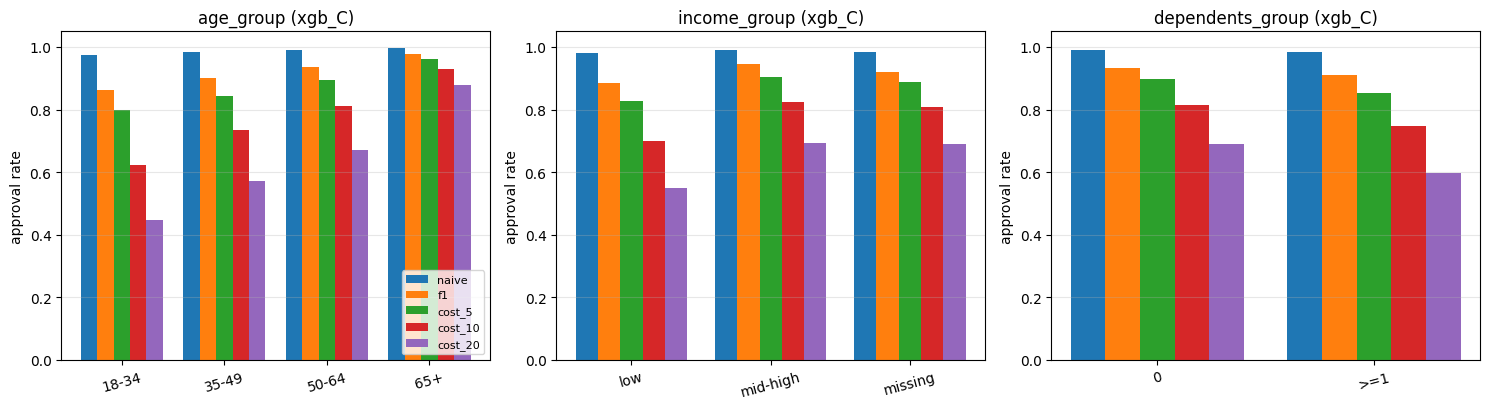

In [10]:
# Approval rate by subgroup for the XGBoost model under all five policies - the visual
# summary of the analysis: cost-sensitive thresholds lower approval for everyone, but
# much more steeply for the young, low-income and high-dependency groups.
key = selected["xgb"]
p = probabilities[key]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, dimension in zip(axes, ("age_group", "income_group", "dependents_group")):
    names = sorted(groups[dimension].unique())
    x = np.arange(len(names))
    width = 0.16
    for j, (label, t) in enumerate(policy_thresholds(key).items()):
        values = [np.mean(p[(groups[dimension] == g).to_numpy()] < t) for g in names]
        ax.bar(x + (j - 2) * width, values, width, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{dimension} ({key})")
    ax.set_ylabel("approval rate")
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

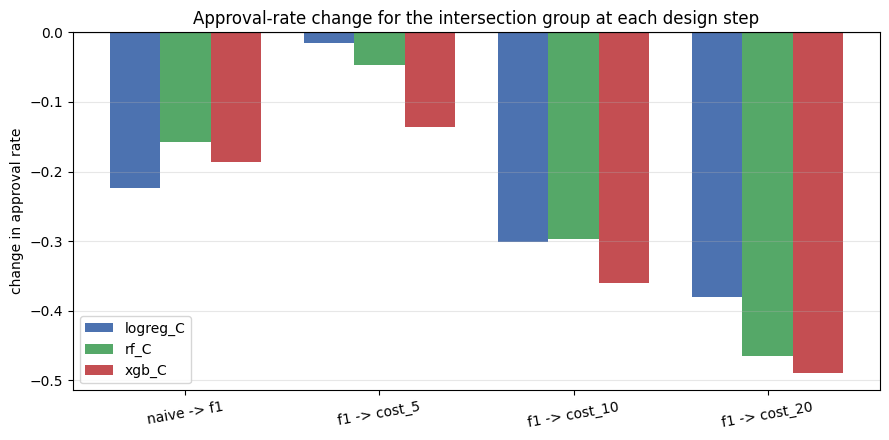

In [11]:
# Change in approval rate for the intersection group at each design step, per model -
# the headline chart: the discrimination step (naive -> F1) already removes around 20
# percentage points of approval, and the high-asymmetry cost step removes far more.
fig, ax = plt.subplots(figsize=(9, 4.5))
steps = ["naive -> f1"] + [f"f1 -> cost_{r}" for r in COST_RATIOS]
x = np.arange(len(steps))
width = 0.26
colors = {"logreg": "#4C72B0", "rf": "#55A868", "xgb": "#C44E52"}
for j, (family, key) in enumerate(selected.items()):
    sub = decomposition[(decomposition.model == key)
                        & (decomposition.group == "intersection")].set_index("step")
    ax.bar(x + (j - 1) * width, sub.loc[steps, "delta_approval"], width,
           label=key, color=colors[family])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(steps, rotation=10)
ax.set_ylabel("change in approval rate")
ax.set_title("Approval-rate change for the intersection group at each design step")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Persist the full subgroup analysis as an artifact, so every number quoted in the
# thesis's societal section is evidenced by a file rather than by notebook output:
# the tier-1 tables, the tier-2 table with bootstrap CIs, the three-threshold
# decomposition with paired-delta CIs, and the intersection definition itself.
subgroup_results = {
    "seed": SEED,
    "n_bootstrap": N_BOOTSTRAP,
    "income_q33_train": float(income_q33),
    "intersection": {
        "definition": "age 18-34 AND (low OR missing income) AND >=1 dependent",
        "n": int(intersection.sum()),
        "share_of_test": float(intersection.mean()),
        "default_rate": float(y_test[intersection].mean()),
        "default_rate_complement": float(y_test[~intersection].mean()),
    },
    "tier1": [{"dimension": dimension, "model": key,
               "table": table.round(6).to_dict(orient="records")}
              for (dimension, key), table in tier1_tables.items()],
    "tier2": tier2.round(6).to_dict(orient="records"),
    "decomposition": decomposition.round(6).to_dict(orient="records"),
}
(ARTIFACTS / "subgroup_results.json").write_text(json.dumps(subgroup_results, indent=2))
print("saved: subgroup_results.json")

saved: subgroup_results.json
